In [3]:
import pandas as pd

orders_url = "https://drive.google.com/file/d/143CzG5DriVSPMkaL1UP4k3Y80oS8fgbV/view?usp=sharing"
orderlines_url = "https://drive.google.com/file/d/1yWO-mQfxQtnSZdCgdNlIEUrZSCW1HN5O/view?usp=sharing"
products_url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
brands_url = "https://drive.google.com/file/d/1XGyabaa4mAkjixMk3XPgx_14OoSse3rs/view?usp=sharing"

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)

orderlines_qu = import_csv(orderlines_url)
orderlines_qu['date'] = pd.to_datetime(orderlines_qu['date'])
orders_qu = import_csv(orders_url)
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])
products_cl = import_csv(products_url)
brands_df = import_csv(brands_url)

#### Exercise 1: Merge the brands and products data frames into the orderlines data frame

In [17]:
ol = orderlines_qu.merge(
    products_cl,
    on="sku",
    how="left"
)


##### Hint:

`.merge()`<br>
To merge in brands, you will need to match the short brand names with the first three letters of the sku using the string accessor (`.str`) and slices `[:]`

#### Exercise 2: Create a column called `'revenue'` in the orderlines data frame by multiplying the unit price by the quantity, and a column called `'percentage discount'` by comparing the price from the products table with the price in the orderlines table

In [18]:
ol["unit_price"] = pd.to_numeric(ol["unit_price"], errors="coerce")
ol["product_quantity"] = pd.to_numeric(ol["product_quantity"], errors="coerce")
ol["price"] = pd.to_numeric(ol["price"], errors="coerce")

ol["revenue"] = ol["unit_price"] * ol["product_quantity"]
ol["percentage_discount"] = ((ol["price"] - ol["unit_price"]) / ol["price"]) * 100


##### Hint:

`df[] = df[] * df[]`<br>
`df[] = 100 * (df[] - df[]) / df[]`

#### Exercise 3: Get the top 10 brands with the most revenue

In [19]:
top10_products = (
    ol.groupby(["sku", "name"])["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top10_products


,,revenue
sku,name,
LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83
APP2446,Apple iPhone 6 32GB Space Gray,104560.64
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,86473.26
APP2477,Apple iPhone 64GB Space Gray 8,85301.93
APP1970,Apple iPhone 32GB Space Gray,80715.76
APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",74964.06
APP2485,Apple iPhone 8 Plus 64GB Gold,70721.79
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96
APP2483,Apple iPhone 8 Plus 64GB Space Gray,60090.08


##### Hint:

`.groupby().agg().nlargest()`

#### Exercise 4: Plot the monthly revenue from apple products

/tmp/ipython-input-2664545280.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


<Axes: title={'center': 'Monthly revenue from Apple products'}, xlabel='Month', ylabel='Revenue'>

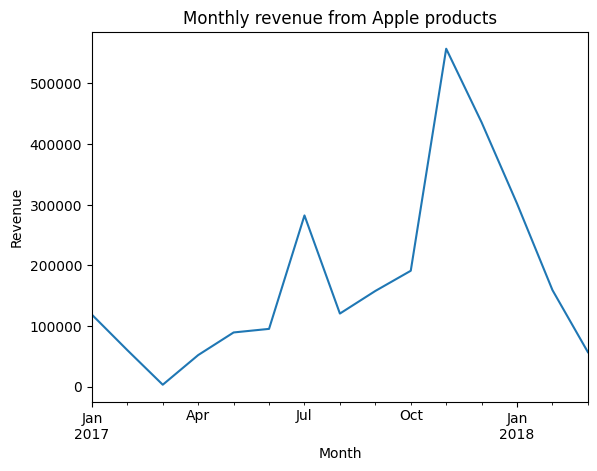

In [20]:
apple = ol[ol["name"].str.contains("apple", case=False, na=False)].copy()

monthly_apple_revenue = (
    apple.set_index("date")
         .resample("M")["revenue"]
         .sum()
)

monthly_apple_revenue.plot(
    title="Monthly revenue from Apple products",
    xlabel="Month",
    ylabel="Revenue"
)


##### Hint:

`.loc[].resample().agg().plot()`

#### Exercise 5: Plot the average monthly discount of apple products (ignore the product quantity)

/tmp/ipython-input-2976985872.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["percentage_discount"]


<Axes: title={'center': 'Average monthly discount (Apple) — unweighted'}, xlabel='Month', ylabel='Avg discount (%)'>

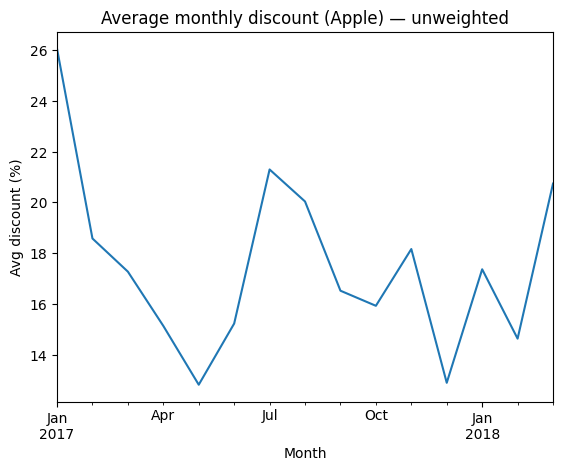

In [21]:
monthly_apple_discount = (
    apple.set_index("date")
         .resample("M")["percentage_discount"]
         .mean()
)

monthly_apple_discount.plot(
    title="Average monthly discount (Apple) — unweighted",
    xlabel="Month",
    ylabel="Avg discount (%)"
)


##### Hint:

`.loc[].resample().agg().plot`

#### Bonus: Repeat the previous exercise, taking quantity into account (orderlines with a quantity of 2 should have twice the weight in the average)

/tmp/ipython-input-3796848239.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


<Axes: title={'center': 'Average monthly discount (Apple) — weighted by quantity'}, xlabel='Month', ylabel='Weighted avg discount (%)'>

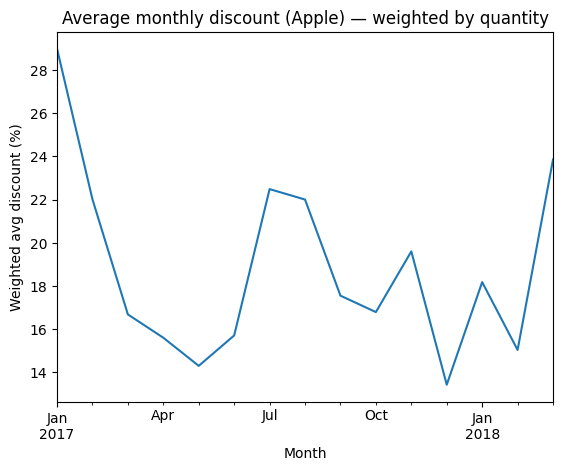

In [22]:
apple["discount_x_qty"] = apple["percentage_discount"] * apple["product_quantity"]

tmp = (
    apple.set_index("date")
         .resample("M")
         .agg(
             total_discount_x_qty=("discount_x_qty", "sum"),
             total_qty=("product_quantity", "sum")
         )
)

tmp["weighted_avg_discount"] = tmp["total_discount_x_qty"] / tmp["total_qty"]

tmp["weighted_avg_discount"].plot(
    title="Average monthly discount (Apple) — weighted by quantity",
    xlabel="Month",
    ylabel="Weighted avg discount (%)"
)


##### Hints 1 and 2:

The `.agg()` will not use `'mean'`<br><br>
Remember how we got the average unit price by dividing the total revenue by the total quantity. We can do something similar here although it is less intuitive with percentages.

##### Hints 3 and 4:

Create a new column mutliplying the percentage discount by the quantity.<br><br>
Resample with two aggregations, then create a new column combining their results and plot the new column

#### Bonus Bonus: Turn the code from the bonus exercise into a function that can take the quantity into account for any time you want to plot an average over time

In [23]:
import pandas as pd

def plot_weighted_avg_over_time(
    df,
    date_col,
    value_col,
    weight_col,
    freq="M",
    title=None,
    xlabel="Time",
    ylabel=None
):
    """
    Plots a weighted average of `value_col` over time using `weight_col` as weights.
    Weighted avg = sum(value * weight) / sum(weight)

    Returns: result_df (with weighted_avg column)
    """
    d = df[[date_col, value_col, weight_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
    d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce")

    d = d.dropna(subset=[date_col, value_col, weight_col])
    d = d[d[weight_col] > 0]

    d["value_x_weight"] = d[value_col] * d[weight_col]

    res = (
        d.set_index(date_col)
         .resample(freq)
         .agg(
             total_value_x_weight=("value_x_weight", "sum"),
             total_weight=(weight_col, "sum")
         )
    )

    res["weighted_avg"] = res["total_value_x_weight"] / res["total_weight"]

    ax = res["weighted_avg"].plot(
        title=title or f"Weighted average of {value_col} over time",
        xlabel=xlabel,
        ylabel=ylabel or f"Weighted avg {value_col}"
    )

    return res


/tmp/ipython-input-1376800321.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample(freq)


,total_value_x_weight,total_weight,weighted_avg
date,,,
2017-01-31,34789.768947,1200,28.991474
2017-02-28,9795.459337,445,22.012268
2017-03-31,483.645972,29,16.677447
2017-04-30,5193.961779,333,15.597483
2017-05-31,6375.140591,446,14.294037


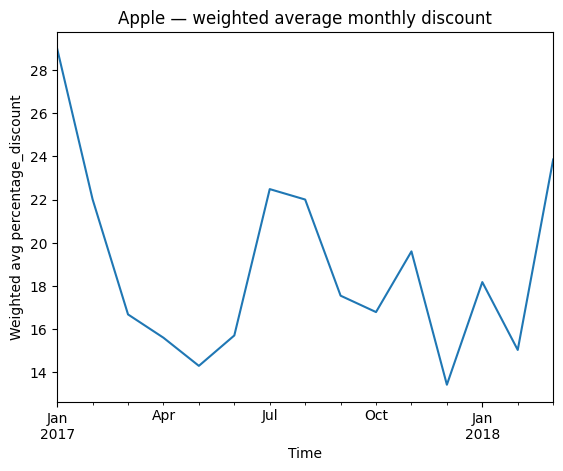

In [24]:
apple = ol[ol["name"].str.contains("apple", case=False, na=False)].copy()

weighted_monthly_discount = plot_weighted_avg_over_time(
    df=apple,
    date_col="date",
    value_col="percentage_discount",
    weight_col="product_quantity",
    freq="M",
    title="Apple — weighted average monthly discount"
)

weighted_monthly_discount.head()
